In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import xgboost
import networkx as nx
from utils.config_loader import load_config
from sklearn.ensemble import IsolationForest
from imblearn.over_sampling import SMOTE
import sys
sys.path.append('D:/Projects/fraud-detection-shap-aws')
from utils.config_loader import load_config

print("pandas    :", pd.__version__)
print("xgboost   :", xgboost.__version__)
print("networkx  :", nx.__version__)
print("shap      :", shap.__version__)
print("\n All libraries ready")

pandas    : 3.0.3
xgboost   : 3.3.0
networkx  : 3.6.1
shap      : 0.52.0

 All libraries ready


In [7]:
#Load Config
config = load_config('D:/Projects/fraud-detection-shap-aws/configs/creditcard_config.json')
#Load Dataset
df = pd.read_csv(f"D:/Projects/fraud-detection-shap-aws/{config['file_path']}")

#Detect Fraud Stats
fraud_count = df[config['target_column']].sum()
legit_count = len(df) / fraud_count
fraud_rate = fraud_count / len(df)
scale_pos_weight = legit_count / fraud_count
contamination = fraud_rate

print(f"\nDataset : {config['dataset_name']}")
print(f"Shape : {df.shape}")
print(f"Fraud : {fraud_count} ({fraud_rate*100:.3f}%)")
print(f"Legit : {legit_count}")
print(f"scale_pos_weight : {scale_pos_weight:.4f}")
print(f"contamination : {contamination:.4f}")
print("\n Dataset Loaded Successfully")
df.head()

Config loaded: Credit Card Fraud

Dataset : Credit Card Fraud
Shape : (284807, 31)
Fraud : 492 (0.173%)
Legit : 578.8760162601626
scale_pos_weight : 1.1766
contamination : 0.0017

 Dataset Loaded Successfully


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [8]:
# Switch dataset with ONE line change
config2 = load_config('D:/Projects/fraud-detection-shap-aws/configs/paysim_config.json')
df2 = pd.read_csv(f"D:/Projects/fraud-detection-shap-aws/{config2['file_path']}")

fraud2 = df2[config2['target_column']].sum()
rate2 = fraud2 / len(df2)

print(f"Dataset : {config2['dataset_name']}")
print(f"Shape : {df2.shape}")
print(f"Fraud : {fraud2} ({rate2*100:.3f}%)")
print(f"scale_pos_weight : {(len(df2)-fraud2)/fraud2:.1f}")
print("\n Same pipeline. Different dataset. Zero code changes.")

Config loaded: PaySim Mobile Money Fraud
Dataset : PaySim Mobile Money Fraud
Shape : (6362620, 11)
Fraud : 8213 (0.129%)
scale_pos_weight : 773.7

 Same pipeline. Different dataset. Zero code changes.


In [13]:
print("-- Data Types --")
print(df.dtypes)
print("\n -- Missing Values --")
print(df.isnull().sum())
print("\n -- Basic Stats --")
print(df[['Amount','Time','Class']].describe())

-- Data Types --
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

 -- Missing Values --
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

 -

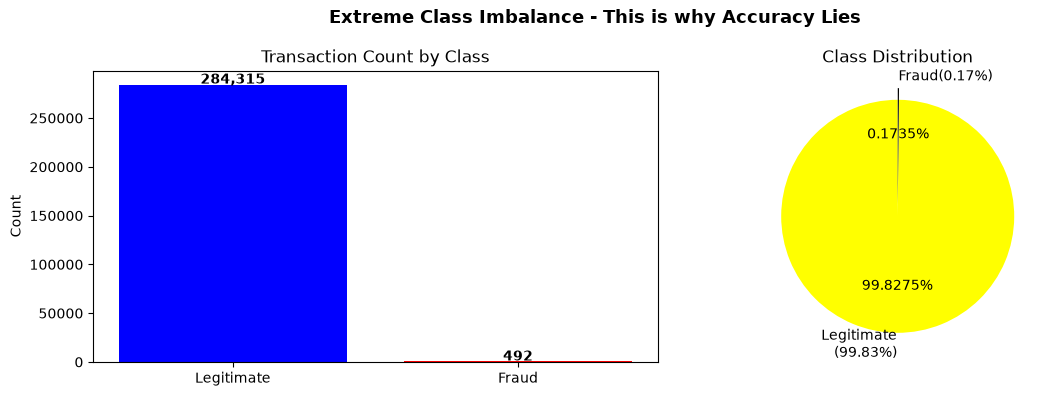

Class imbalance chart saved


In [21]:
fig, axes = plt.subplots(1,2,figsize = (12,4))

# Chart 1 - Count Bar(Bar plot)
class_counts = df['Class'].value_counts()
axes[0].bar(['Legitimate','Fraud'],
            class_counts.values,
            color = ['blue','red'])
axes[0].set_title('Transaction Count by Class')
axes[0].set_ylabel('Count')
for i,v in enumerate(class_counts.values):
    axes[0].text(i,v+1000,f'{v:,}', ha = 'center', fontweight = 'bold')

# Chart 2 - Percentage pie(Pie chart)
axes[1].pie(class_counts.values,
            labels = ['Legitimate\n(99.83%)','Fraud(0.17%)'],
            colors = ['yellow','black'],
            explode = [0,0.1],
            autopct = '%1.3f5%%',
            startangle =  90)
axes[1].set_title('Class Distribution')

plt.suptitle('Extreme Class Imbalance - This is why Accuracy Lies',
             fontsize = 13, fontweight = 'bold')
plt.tight_layout()
plt.savefig('D:/Projects/fraud-detection-shap-aws/reports/shap_plots/class_imbalance.png',
            dpi = 150, bbox_inches = 'tight')
plt.show()
print("Class imbalance chart saved")

In [22]:
# Metric Choice

total = len(df)
fraud = df['Class'].sum()
legit = total - fraud

print("=" * 50)
print("WHY ACCURACY IS USELESS FOR FRAUD DETECTION")
print("=" * 50)
print(f"\nIf model predicts 'NOT FRAUD' for every transaction:")
print(f"  Correct predictions : {legit:,}")
print(f"  Wrong predictions   : {fraud:,}")
print(f"  Accuracy            : {legit/total*100:.2f}%")
print(f"  Fraud caught        : 0 out of {fraud}")
print(f"\n→ 99.83% accuracy. Zero fraud detected.")
print(f"→ This is why we use Precision-Recall AUC instead.")
print("=" * 50)

WHY ACCURACY IS USELESS FOR FRAUD DETECTION

If model predicts 'NOT FRAUD' for every transaction:
  Correct predictions : 284,315
  Wrong predictions   : 492
  Accuracy            : 99.83%
  Fraud caught        : 0 out of 492

→ 99.83% accuracy. Zero fraud detected.
→ This is why we use Precision-Recall AUC instead.


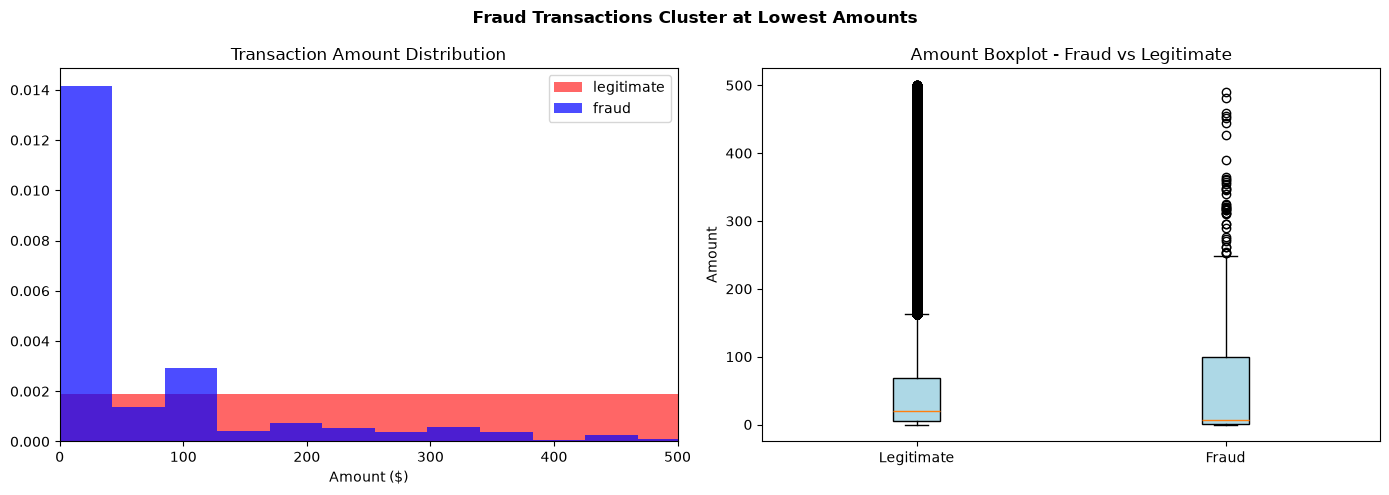

 Avg legitimate amount : $88.29
 Avg Fraud amount      : $122.21
 Max Fraud amount      : $2125.87
 Max Legitimate amount : $25691.16


In [35]:
fig, axes = plt.subplots(1, 2, figsize = (14,5))

#KDE Plot - fraud vs legit amount
fraud_amounts = df[df['Class']==1]['Amount']
legit_amounts = df[df['Class']==0]['Amount']
axes[0].hist(legit_amounts, bins=50, alpha=0.6,
             color = 'red', label = 'legitimate', density = True)
axes[0].hist(fraud_amounts, bins=50, alpha=0.7,
             color = 'blue', label = 'fraud', density = True)
axes[0].set_xlim(0,500)
axes[0].set_title('Transaction Amount Distribution')
axes[0].set_xlabel('Amount ($)')
axes[0].legend()

#Box plot
data_to_plot =[legit_amounts[legit_amounts < 500],
               fraud_amounts[fraud_amounts < 500]]
axes[1].boxplot(
    data_to_plot,
    tick_labels=['Legitimate','Fraud'],
    patch_artist=True,
    boxprops=dict(facecolor='lightblue')
)
axes[1].set_title('Amount Boxplot - Fraud vs Legitimate')
axes[1].set_ylabel('Amount')

plt.suptitle('Fraud Transactions Cluster at Lowest Amounts',
             fontsize = 12, fontweight = 'bold')
plt.tight_layout()
plt.savefig('D:/Projects/fraud-detection-shap-aws/reports/shap_plots/amount_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(f" Avg legitimate amount : ${legit_amounts.mean():.2f}")
print(f" Avg Fraud amount      : ${fraud_amounts.mean():.2f}")
print(f" Max Fraud amount      : ${fraud_amounts.max():.2f}")
print(f" Max Legitimate amount : ${legit_amounts.max():.2f}")

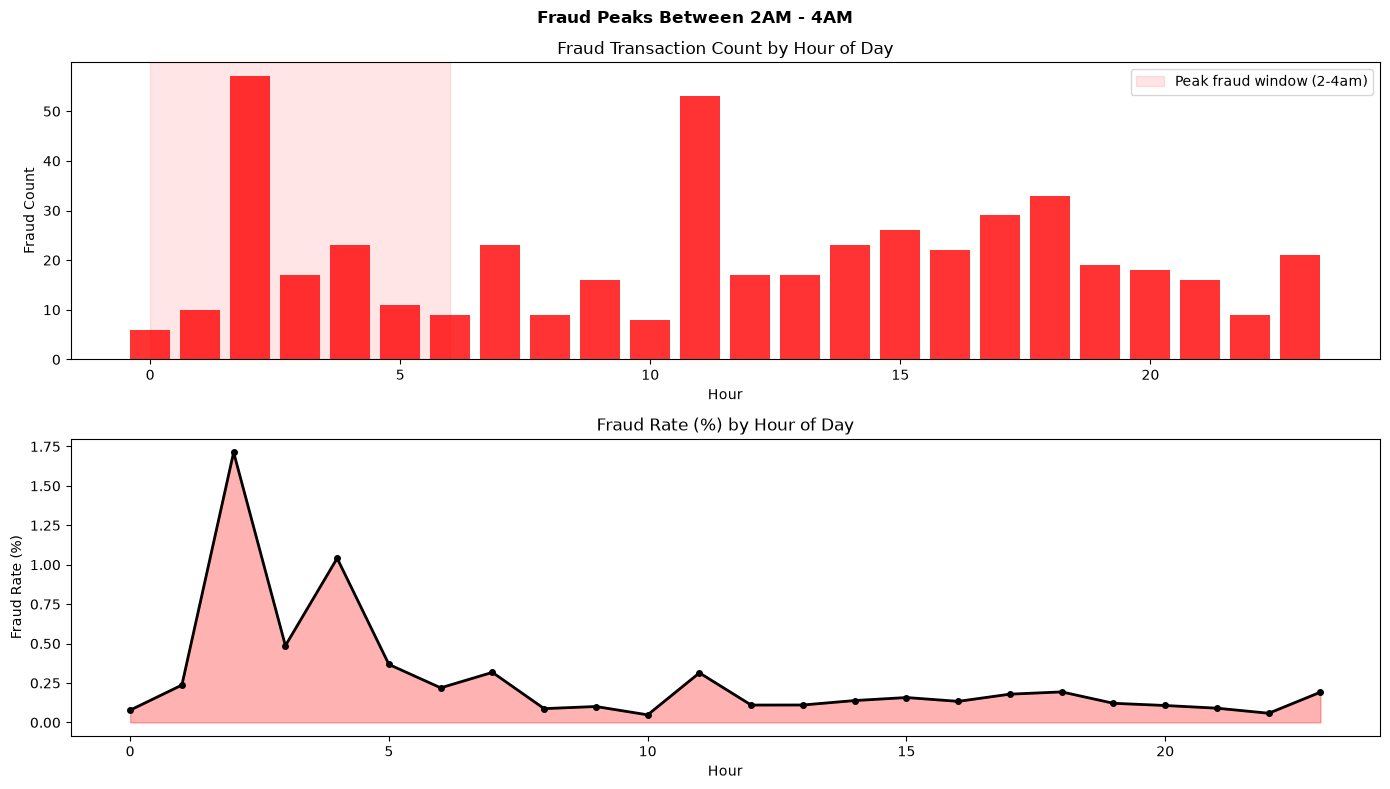

Peak fraud hour : 2:00
Fraud at peak   : 57 transactions


In [44]:
#converting time(seconds) to hours
df['Hour'] = (df['Time'] / 3600 % 24).astype(int)

fraud_by_hour = df[df['Class']==1].groupby('Hour').size()
legit_by_hour = df[df['Class']==0].groupby('Hour').size()
fraud_rate_by_hour = (fraud_by_hour / 
                      (fraud_by_hour + legit_by_hour.reindex(fraud_by_hour.index, fill_value = 0)) *100)
fig, axes = plt.subplots(2,1, figsize = (14,8))

#Fraud count by hour
axes[0].bar(fraud_by_hour.index, fraud_by_hour.values, color='red', alpha=0.8)
axes[0].set_title('Fraud Transaction Count by Hour of Day')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Fraud Count')
axes[0].axvspan(0, 6, alpha=0.1, color='red', label='Peak fraud window (2-4am)')
axes[0].legend()

# Fraud rate by hour
axes[1].plot(fraud_rate_by_hour.index, fraud_rate_by_hour.values, 
             color='black', linewidth=2, marker='o', markersize=4)
axes[1].set_title('Fraud Rate (%) by Hour of Day')
axes[1].set_xlabel('Hour')
axes[1].set_ylabel('Fraud Rate (%)')
axes[1].fill_between(fraud_rate_by_hour.index, fraud_rate_by_hour.values, alpha=0.3, color='red')

plt.suptitle('Fraud Peaks Between 2AM - 4AM', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('D:/Projects/fraud-detection-shap-aws/reports/shap_plots/fraud_by_hour.png',
            dpi=150, bbox_inches='tight')
plt.show()

peak_hour = fraud_by_hour.idxmax()
print(f"Peak fraud hour : {peak_hour}:00")
print(f"Fraud at peak   : {fraud_by_hour[peak_hour]} transactions")

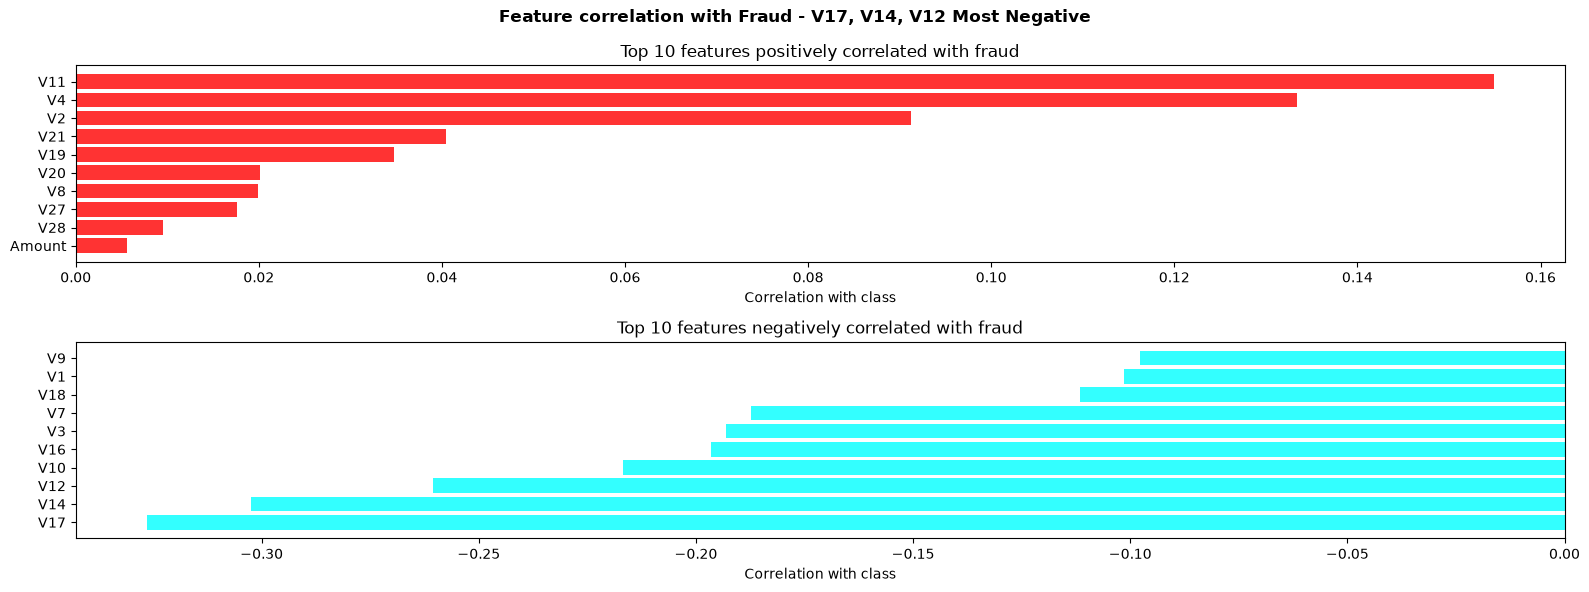

Top 5 fraud indicators (positive): 
V19    0.034783
V21    0.040413
V2     0.091289
V4     0.133447
V11    0.154876

 Top 5 fraud indicators (negative): 
V17   -0.326481
V14   -0.302544
V12   -0.260593
V10   -0.216883
V16   -0.196539


In [48]:
#Top features correlated with fraud 
correlations = df.corr()['Class'].drop('Class').sort_values()

fig, axes = plt.subplots(2, 1, figsize = (16,6))

#Top 10 positive correlations 
top_positive = correlations.tail(10)
axes[0].barh(top_positive.index, top_positive.values, color = 'red' , alpha = 0.8)
axes[0].set_title('Top 10 features positively correlated with fraud')
axes[0].set_xlabel('Correlation with class')
axes[0].axvline(x=0, color = 'black', linewidth = 0.5)

#Top 10 positive correlations 
top_negative = correlations.head(10)
axes[1].barh(top_negative.index, top_negative.values, color = 'cyan', alpha = 0.8)
axes[1].set_title('Top 10 features negatively correlated with fraud')
axes[1].set_xlabel('Correlation with class')
axes[1].axvline(x=0, color = 'black', linewidth = 0.5)

plt.suptitle('Feature correlation with Fraud - V17, V14, V12 Most Negative',
             fontsize=12, fontweight = 'bold')
plt.tight_layout()
plt.savefig('D:/Projects/fraud-detection-shap-aws/reports/shap_plots/correlation_chart.png',
            dpi=150, bbox_inches='tight')
plt.show()


print("Top 5 fraud indicators (positive): ")
print(correlations.tail(5).to_string())
print("\n Top 5 fraud indicators (negative): ")
print(correlations.head(5).to_string())

In [53]:
from sklearn.preprocessing import RobustScaler

# Scale Amount and Time - V1-V28 already PCA scaled
scaler = RobustScaler()
df['Amount_Scaled'] = scaler.fit_transform(df[['Amount']])
df['Time_Scaled']   = scaler.fit_transform(df[['Time']])

# Drop original unscaled columns
df_model = df.drop(['Amount', 'Time', 'Hour'], axis = 1)

print(f"Model dataset shape : {df_model.shape}")
print(f"Columns             : {list(df_model.columns[:5])}... + Amount_Scaled,Time_Scaled")
print("Features scaled and ready for ML")

# Save processed dataset
df_model.to_csv('D:/Projects/fraud-detection-shap-aws/data/processed/creditcard_processed.csv', 
                index=False)
print(" Processed dataset saved to data/processed/")

Model dataset shape : (284807, 31)
Columns             : ['V1', 'V2', 'V3', 'V4', 'V5']... + Amount_Scaled,Time_Scaled
Features scaled and ready for ML
 Processed dataset saved to data/processed/


In [54]:
from sklearn.model_selection import train_test_split

# Load config values
target = config ['target_column']

X = df_model.drop(target, axis = 1)
y = df_model[target]

# Stratified split — preserves 0.17% fraud ratio in both sets

X_train,X_test,y_train,y_test = train_test_split(
    X, y,
    test_size= 0.2,
    random_state = 42,
    stratify = y)

print(f"Training Set  : {X_train.shape}")
print(f"Test Set      : {X_test.shape}")
print(f"\n Fraud in train : {y_train.sum()} ({y_train.mean()*100:.3f}%)")
print(f"Fraud in test     : {y_test.sum()} ({y_test.mean()*100:.3f}%)")
print("\n Stratified split complete — fraud ratio preserved in both sets")

Training Set  : (227845, 30)
Test Set      : (56962, 30)

 Fraud in train : 394 (0.173%)
Fraud in test     : 98 (0.172%)

 Stratified split complete — fraud ratio preserved in both sets
